In [37]:
import numpy as np
import pandas as pd
import re
from typing import Dict, Any, List

import matplotlib.pyplot as plt
import seaborn as sns

import umap
from sklearn.cluster import KMeans

import json

In [38]:
import warnings

warnings.filterwarnings("ignore", message=".*gradient function is not yet implemented.*")
warnings.filterwarnings("ignore", message=".*n_jobs value 1 overridden.*")

In [39]:
INPUT_CSV = "../data/ground_truth/nanozymes.csv"

In [ ]:
# Настройка цветов в стиле презентации
bg_color = "#020202"  # Очень темный фон
text_color = "#A291F0" # Светло-фиолетовый (как на слайде)
grid_color = "#252535"

# 1. Применяем базовую темную тему и переопределяем параметры
plt.rcParams.update({
    "figure.facecolor": bg_color,
    "axes.facecolor": bg_color,
    "axes.edgecolor": text_color,
    "axes.labelcolor": text_color,
    "axes.titlecolor": text_color,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "grid.color": grid_color,
    "legend.facecolor": bg_color,
    "legend.edgecolor": text_color,
    "text.color": text_color,
    "font.family": "sans-serif", # В идеале установить Montserrat, если есть
})

# Конфигурация

## Полнота покрытия извлекаемых параметров

In [41]:
# Для % заполненных параметров
PARAMETERS = [
    'formula', 'activity', 'syngony', 'length', 'surface',
    'km_value', 'vmax_value', 'reaction_type',
    'c_min', 'c_max', 'c_const', 'ph', 'temperature'
]

# Для вариативности в ключевом параметре — reaction_type
SUBSTRATES = ['TMB', 'ABTS', 'OPD', 'DAB']

% заполненных полей

In [42]:
def _calculate_density(group: pd.DataFrame, fields: List[str]) -> float:
    """Считает процент заполненных ячеек в целевых колонках."""
    valid_cols = [c for c in fields if c in group.columns]
    if not valid_cols:
        return 0.0
    
    # Считаем не-NaN и не пустые строки
    filled_count = group[valid_cols].notna().sum().sum()
    total_slots = len(group) * len(fields)
    return filled_count / total_slots if total_slots > 0 else 0.0

def has_high_density(group: pd.DataFrame, fields: List[str], threshold: float = 0.85) -> bool:
    """Проверяет статью на высокую информационную плотность."""
    return _calculate_density(group, fields) > threshold

Переключение ролей субстрата

In [43]:
def has_substrate_switch(group: pd.DataFrame) -> bool:
    """Проверяет наличие переключения ролей субстрата и ко-субстрата."""
    r_types = group['reaction_type'].dropna().astype(str).str.strip().str.upper().unique()
    has_normal = any(
        any(r.startswith(s) for s in SUBSTRATES) and 'H2O2' in r 
        for r in r_types
    )
    has_reverse = any(
        r.startswith('H2O2') and any(s in r for s in SUBSTRATES) 
        for r in r_types
    )
    return has_normal and has_reverse

Вариативность субстрата

In [44]:
def has_substrate_variety(group: pd.DataFrame) -> bool:
    """Проверяет, используется ли в статье более одного типа субстрата."""
    r_types = group['reaction_type'].dropna().astype(str).str.strip().str.upper().unique()
    found_substrates = {s for s in SUBSTRATES if any(s in r for r in r_types)}
    return len(found_substrates) > 1

Множественность экспериментов

In [45]:
def has_multi_experiment(group: pd.DataFrame, threshold: int = 4) -> bool:
    """Проверяет, содержит ли статья много экспериментов (по умолчанию >= 4)."""
    return len(group) >= threshold

## Полнота покрытия мест извлечения

In [46]:
SI_SOURCES = {'si'}

In [47]:
def has_si(group: pd.DataFrame) -> bool:
    """Проверяет, есть ли данные из SI."""
    sources = set(group['target_source'].dropna().astype(str).str.lower().unique())
    return bool(sources & SI_SOURCES)

## Полнота покрытия записи параметров

Экспоненциальная запись типа 1.5E-05 или 100^-5, 10 -6

In [48]:
SCI_NOT_RE = re.compile(r'(?:E[+-]?\d)|(?:10\s*[-−^]\s*\d)', re.IGNORECASE)

def has_sci_notation(group: pd.DataFrame) -> bool:
    """Проверяет наличие научной нотации в численных значениях (Km/Vmax)."""
    num_cols = [c for c in ['km_value', 'vmax_value'] if c in group.columns]
    if not num_cols:
        return False
    return group[num_cols].astype(str).apply(
        lambda s: s.str.contains(SCI_NOT_RE, na=False)
    ).any().any()

Сложные символы: типографский минус, точка, греческие буквы

In [49]:
COMPLEX_UNIT_CHARS = {'−', '·', 'µ', 'μ', '⋅'}

def has_complex_units(group: pd.DataFrame) -> bool:
    """Проверяет наличие сложных юнитов (греческие буквы, точки, спецтире)."""
    unit_cols = [c for c in ['km_unit', 'vmax_unit', 'ccat_unit'] if c in group.columns]
    if not unit_cols:
        return False
    all_units = group[unit_cols].fillna('').astype(str).values.flatten()
    return any(bool(set(u) & COMPLEX_UNIT_CHARS) for u in all_units)

# Генерация признаков

In [50]:
def extract_features(doi: str, group: pd.DataFrame) -> Dict[str, Any]:
    """Агрегирует результаты всех проверок в единый вектор признаков статьи."""
    
    # Рассчитываем плотность отдельно, так как она нужна и для флага, и для метаданных
    density = _calculate_density(group, PARAMETERS)
    
    # Сборка словаря признаков
    f = {
        'F_Switch': has_substrate_switch(group),
        'F_Variety': has_substrate_variety(group),
        'F_SciNot': has_sci_notation(group),
        'F_Units': has_complex_units(group),
        'F_SI': has_si(group),
        'F_Multi': has_multi_experiment(group),
        'F_Density': has_high_density(group, PARAMETERS)
    }
    
    # Добавляем DOI и расчет итогового балла
    features = {
        'DOI': doi,
        'Experiments': len(group),
        **f,
        'Raw_Density': round(density, 2)
    }
    
    return features

In [51]:
def calculate_weighted_score(row):
    score = 0
    # Логика
    score += 5.0 if row['F_Switch'] else 0

    # Контекст и внимание
    score += 4.0 if row['F_SI'] else 0
    score += 3.5 if row['F_Multi'] else 0
    
    # Информационная насыщенность и разнообразие
    score += 2.0 if row['F_Density'] else 0
    score += 2.0 if row['F_Variety'] else 0
    
    # Форматирование и синтаксис
    score += 1.0 if row['F_Units'] else 0
    score += 1.0 if row['F_SciNot'] else 0
    
    return score

In [52]:
df = pd.read_csv(INPUT_CSV)

# Предобработка
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x) # Удаление пробелов в начале и конце на всякий случай
df = df.replace([r'^\s*$', 'nan', 'NaN', 'None', 'none'], pd.NA, regex=True) # Замена пустот в ячейках на pd.NA

# Принудительно приводим visual к числам, чтобы избежать ошибок сравнения
df['visual'] = pd.to_numeric(df['visual'], errors='coerce').fillna(0)

# Объединение экспериментов в группы по статьям
candidates = []
for doi, group in df.groupby('doi'):
    candidates.append(extract_features(doi, group))
results = pd.DataFrame(candidates)
results['Score'] = results.apply(calculate_weighted_score, axis=1)

print('Статей:', len(results))
display(results.head(30))

Статей: 383


,DOI,Experiments,F_Switch,F_Variety,F_SciNot,F_Units,F_SI,F_Multi,F_Density,Raw_Density,Score
0,10.1002/adfm.201001302,2,True,False,False,True,False,False,True,0.92,8.0
1,10.1002/adfm.201801484,6,True,False,True,False,False,True,False,0.79,9.5
2,10.1002/adfm.202001933,2,True,False,True,False,False,False,False,0.85,6.0
3,10.1002/adhm.201500173,1,False,False,False,False,False,False,False,0.38,0.0
4,10.1002/adhm.202300490,3,False,False,True,False,False,False,False,0.69,1.0
5,10.1002/adma.201203218,4,False,False,True,False,False,True,False,0.85,4.5
6,10.1002/adma.201405105,3,True,False,False,True,True,False,False,0.82,10.0
7,10.1002/ange.201904751,6,True,False,True,True,True,True,False,0.67,14.5
8,10.1002/ange.202115939,2,True,False,True,True,True,False,True,1.00,13.0
9,10.1002/anie.200805279,7,False,False,False,True,False,True,False,0.62,4.5


# Анализ

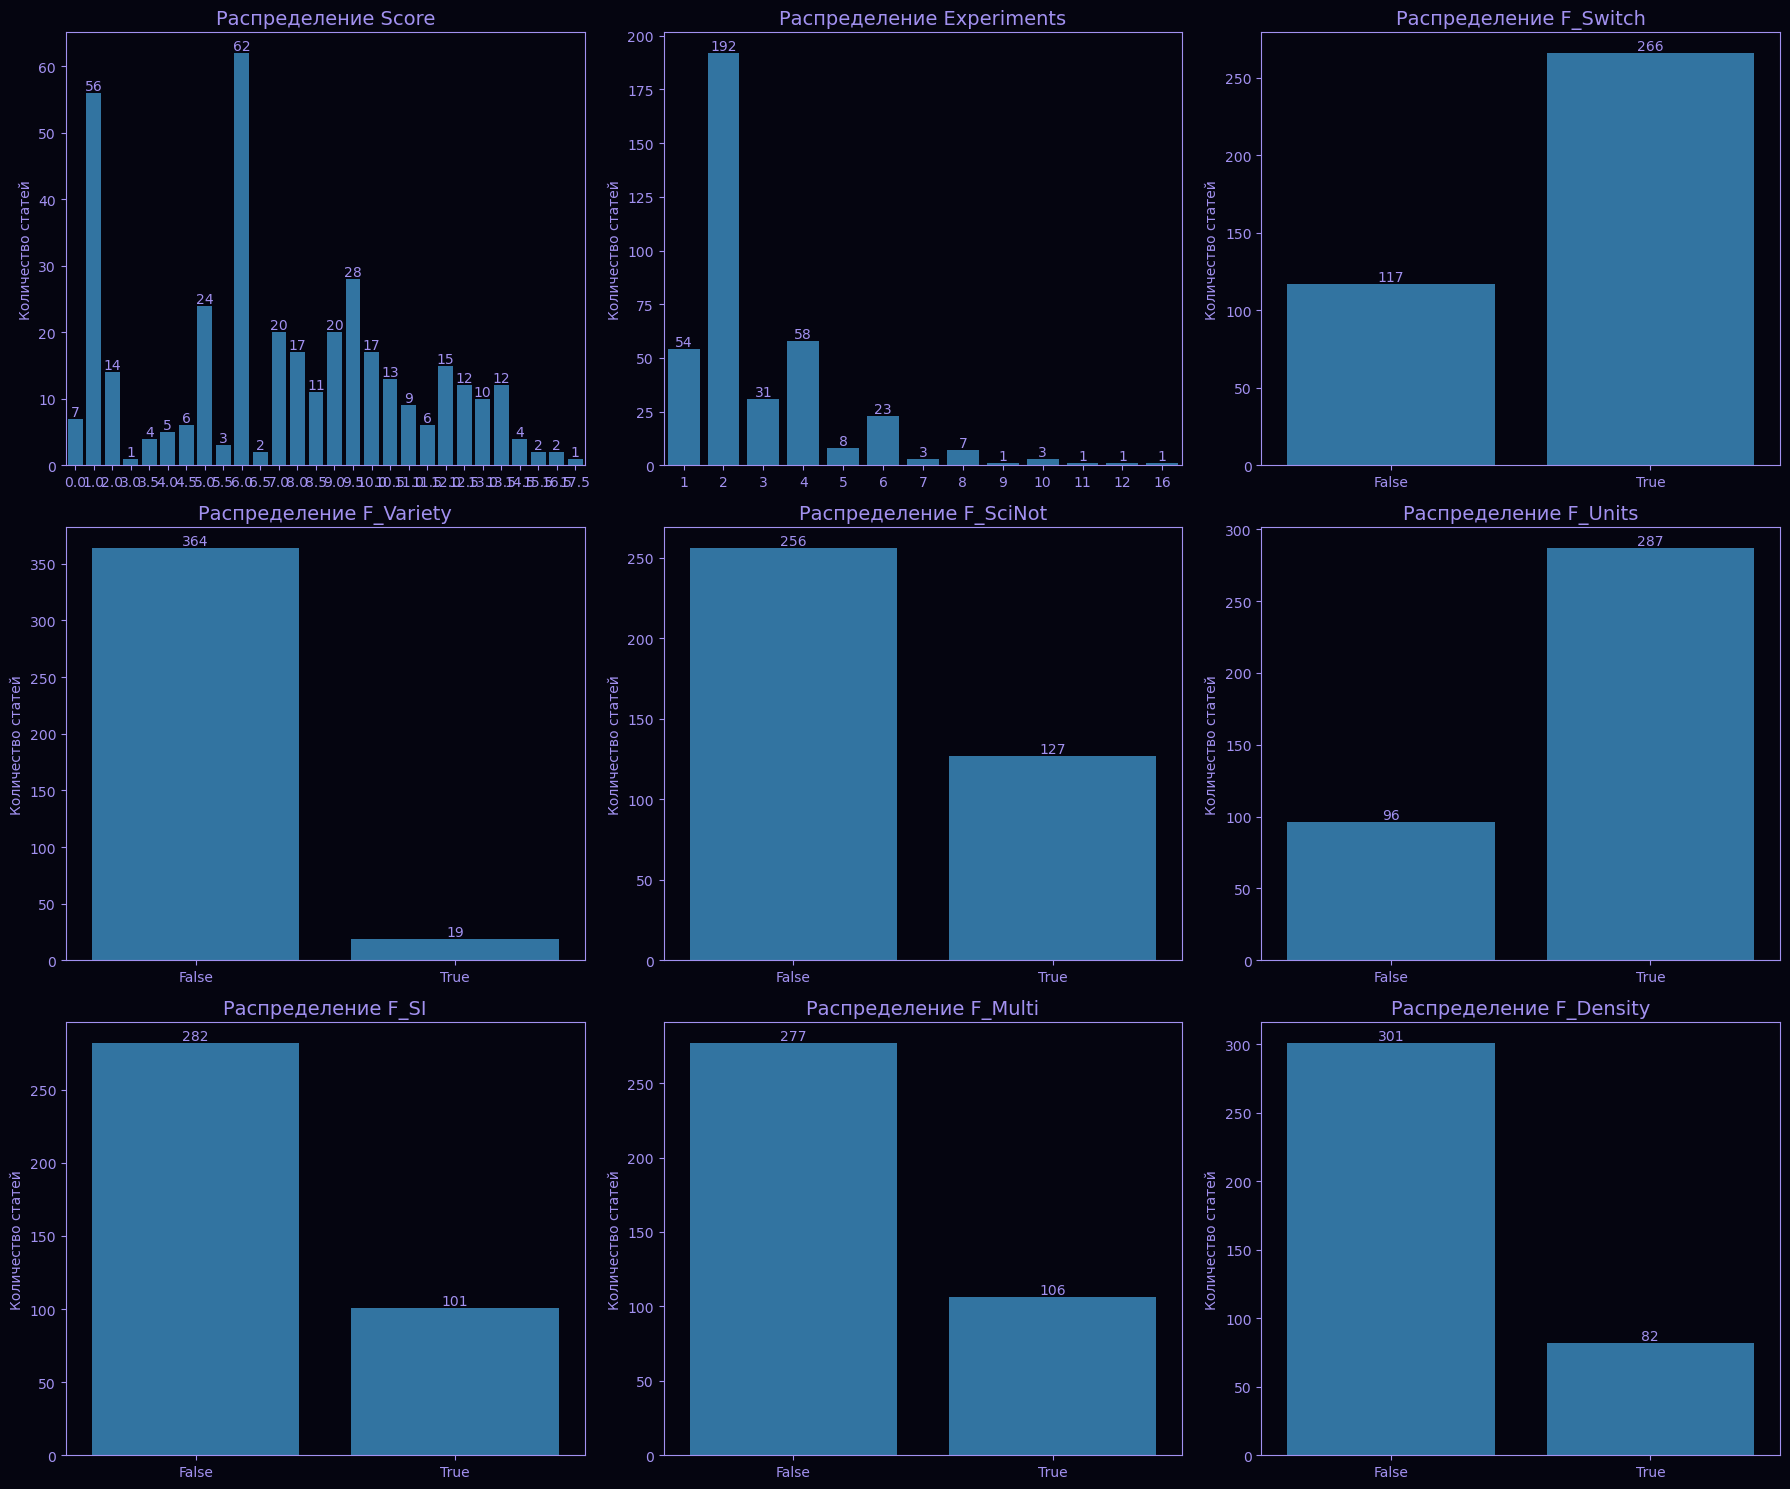

In [53]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

features = ['Score', 'Experiments', 'F_Switch',
            'F_Variety', 'F_SciNot', 'F_Units',
            'F_SI', 'F_Multi', 'F_Density']

for i, feature in enumerate(features):
    ax = axes[i]
    sns.countplot(data=results, x=feature, ax=ax)
    
    ax.set_title(f'Распределение {feature}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Количество статей')
    
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

UMAP для кластеризации

In [54]:
features_for_clustering = [
    'F_Switch', 'F_Variety', 'F_SciNot',
    'F_Units', 'F_SI', 'F_Multi', 'F_Density'
]
X = results[features_for_clustering].copy()

reducer = umap.UMAP(
    n_neighbors=20, 
    min_dist=0.0, 
    n_components=2, 
    random_state=42,
    metric='hamming',
    n_jobs=1
)
embedding = reducer.fit_transform(X)

results['umap_1'] = embedding[:, 0]
results['umap_2'] = embedding[:, 1]

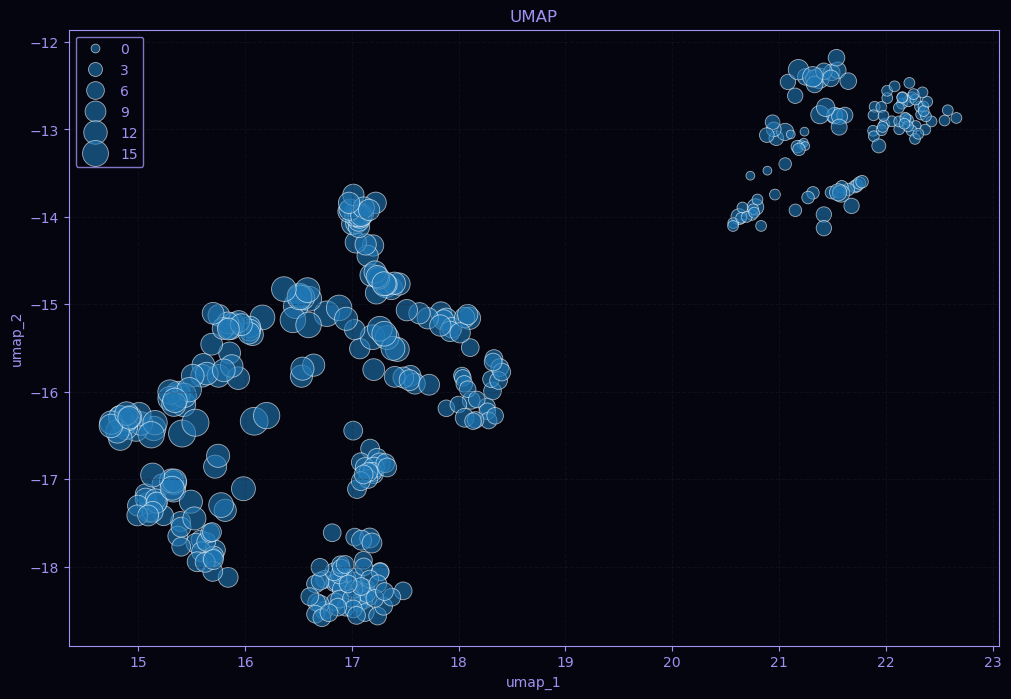

In [55]:
plt.figure(figsize=(12, 8))

umap_1_jitter = results['umap_1'] + np.random.normal(0, 0.05, size=len(results))
umap_2_jitter = results['umap_2'] + np.random.normal(0, 0.05, size=len(results))

sns.scatterplot(
    x=umap_1_jitter, 
    y=umap_2_jitter, 
    size=results['Score'],
    sizes=(40, 400), 
    alpha=0.6,
    edgecolor='white'
)

plt.title('UMAP')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Кластеризация $K$-средних на основе UMAP

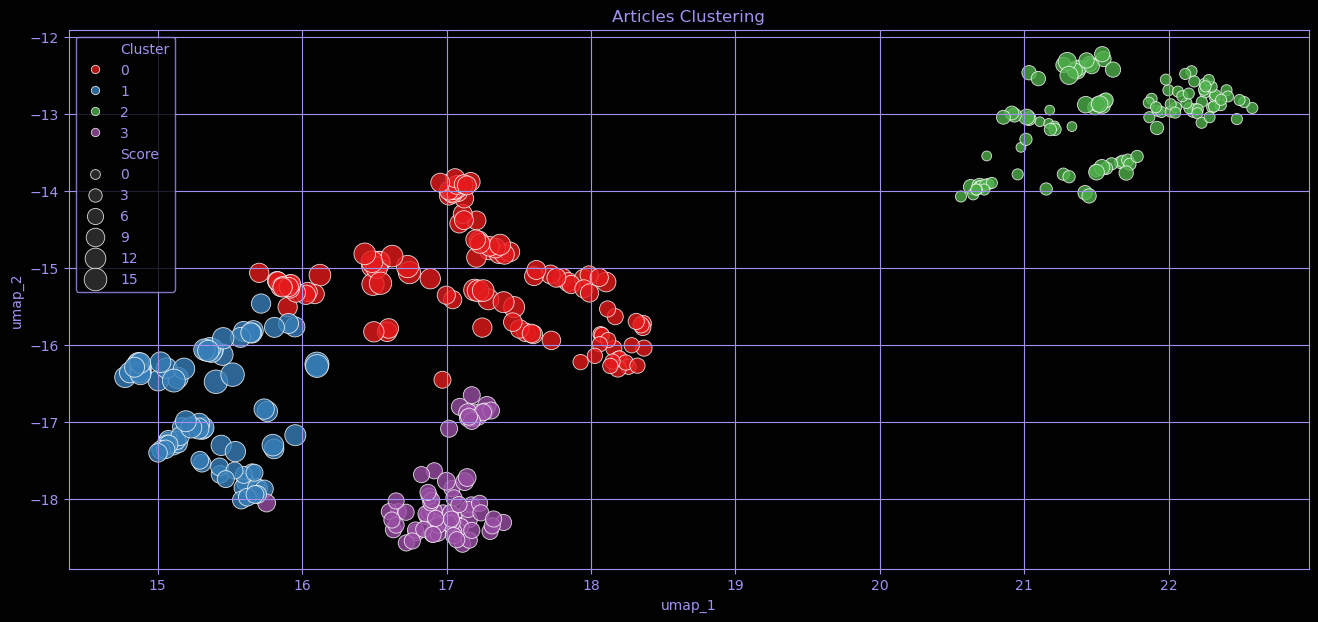

In [83]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
results['Cluster'] = kmeans.fit_predict(embedding)

plt.figure(figsize=(16, 7))
sns.scatterplot(
    data=results, x='umap_1', y='umap_2', 
    hue='Cluster', 
    palette='Set1',
    size='Score', sizes=(50, 300), alpha=0.8
)
plt.title('Articles Clustering')
plt.grid()
plt.show()

# Сэмплирование

In [57]:
# Группировка экспериментов по DOI, фильтрация по visual == 0, сортировка по сложности
text_only_dois = df.groupby('doi').filter(lambda g: (g['visual'] == 0).all())['doi'].unique()
text_only_pool = results[results['DOI'].isin(text_only_dois)] \
    .sort_values('Score', ascending=False) \
    [['DOI', 'Cluster', 'Score']].copy()

# Разбиение на Train и Test
train_pool = text_only_pool.iloc[0:20, :]
val_test_pool = text_only_pool.iloc[20:, :]

## Тренировочная (few-shot) выборка

Ручная — 2 самые сложные статьи

In [58]:
train_manual_dois = train_pool.iloc[:2, 0].tolist()

print(train_manual_dois)

['10.1016/j.jallcom.2016.04.269', '10.1039/C9TB00989B']


Для оптимизации MIPROv2 — 20 самых сложных статей

In [59]:
train_auto_dois = train_pool.iloc[0:20, 0].tolist()

print(train_auto_dois)

['10.1016/j.jallcom.2016.04.269', '10.1039/C9TB00989B', '10.1016/j.jcis.2021.06.170', '10.1007/s00604-019-3395-8', '10.1002/ange.201904751', '10.1016/j.snb.2019.127106', '10.1007/s00604-017-2198-z', '10.1002/ange.202115939', '10.1039/C8TB01948G', '10.1016/j.bios.2014.07.048', '10.1007/s13205-017-1082-1', '10.1016/j.snb.2012.07.070', '10.1021/acsami.0c07886', '10.1038/srep35344', '10.1166/jnn.2018.13977', '10.1039/C9AN01262A', '10.1016/j.jcis.2015.08.032', '10.1016/j.surfin.2021.101109', '10.1002/ppsc.201500043', '10.1002/smll.202105673']


## Валидационная выборка

Отобрать 20 статей пропорционально кластерам

In [60]:
# Пропорции кластеров во всём датасете
cluster_weights = results['Cluster'].value_counts(normalize=True)

# Проекция пропорций на выборку из 20 статей
cluster_plan = (cluster_weights * 20).round().astype(int)
cluster_plan[cluster_plan.idxmax()] += (20 - cluster_plan.sum())

print(cluster_plan)

Cluster
0    6
2    6
1    4
3    4
Name: proportion, dtype: int64


In [61]:
val_dois = []

for cluster_id, count in cluster_plan.items():
    cluster_candidates = val_test_pool[val_test_pool['Cluster'] == cluster_id]
    selected = cluster_candidates.sample(
        min(count, len(cluster_candidates)),
        random_state=42
    )
    val_dois.extend(selected['DOI'].tolist())

print(val_dois)

['10.1007/s10853-018-2657-x', '10.1016/j.snb.2016.08.094', '10.1016/j.microc.2021.106238', '10.1007/s41664-019-00104-0', '10.1039/C5NR08038J', '10.1021/acssuschemeng.9b02459', '10.1039/C5AY01732G', '10.1039/D0NR04177G', '10.1021/acs.analchem.2c05425', '10.1016/j.snb.2023.133540', '10.1039/D0NJ02387F', '10.1007/s00604-017-2326-9', '10.1016/j.colsurfb.2017.02.004', '10.1002/adfm.201001302', '10.1007/s11434-016-1193-9', '10.1039/D0NJ05026A', '10.1039/C8NJ01190G', '10.1016/j.microc.2019.104019', '10.1016/j.apsusc.2019.03.337', '10.1016/j.snb.2016.07.168']


In [62]:
bad_doi = '10.1039/C5NR08038J'

if bad_doi in val_dois:
    target_cluster = results[results['DOI'] == bad_doi]['Cluster'].values[0]    
    
    current_val_set = set(val_dois)
    train_set = set(train_auto_dois)
    
    replacement_pool = val_test_pool[
        (val_test_pool['Cluster'] == target_cluster) & 
        (~val_test_pool['DOI'].isin(current_val_set))
    ]
    
    if not replacement_pool.empty:
        new_selected = replacement_pool.sort_values('Score', ascending=False).iloc[0]
        new_doi = new_selected['DOI']
        
        val_dois = [new_doi if x == bad_doi else x for x in val_dois]
        
        print(f"Статья {bad_doi} (кластер {target_cluster}) успешно заменена на {new_doi}")
        print(f"Новый список валидации: {val_dois}")
    else:
        print(f"Ошибка: В кластере {target_cluster} не нашлось подходящих статей для замены.")
else:
    print(f"Статья {bad_doi} не найдена в текущем списке val_dois.")

Статья 10.1039/C5NR08038J (кластер 0) успешно заменена на 10.1021/ac503544w
Новый список валидации: ['10.1007/s10853-018-2657-x', '10.1016/j.snb.2016.08.094', '10.1016/j.microc.2021.106238', '10.1007/s41664-019-00104-0', '10.1021/ac503544w', '10.1021/acssuschemeng.9b02459', '10.1039/C5AY01732G', '10.1039/D0NR04177G', '10.1021/acs.analchem.2c05425', '10.1016/j.snb.2023.133540', '10.1039/D0NJ02387F', '10.1007/s00604-017-2326-9', '10.1016/j.colsurfb.2017.02.004', '10.1002/adfm.201001302', '10.1007/s11434-016-1193-9', '10.1039/D0NJ05026A', '10.1039/C8NJ01190G', '10.1016/j.microc.2019.104019', '10.1016/j.apsusc.2019.03.337', '10.1016/j.snb.2016.07.168']


Проверка распределения кластеров

In [63]:
val_test_pool[val_test_pool['DOI'].isin(val_dois)]['Cluster'].value_counts() \
    == cluster_plan

Cluster
0    True
2    True
1    True
3    True
dtype: bool

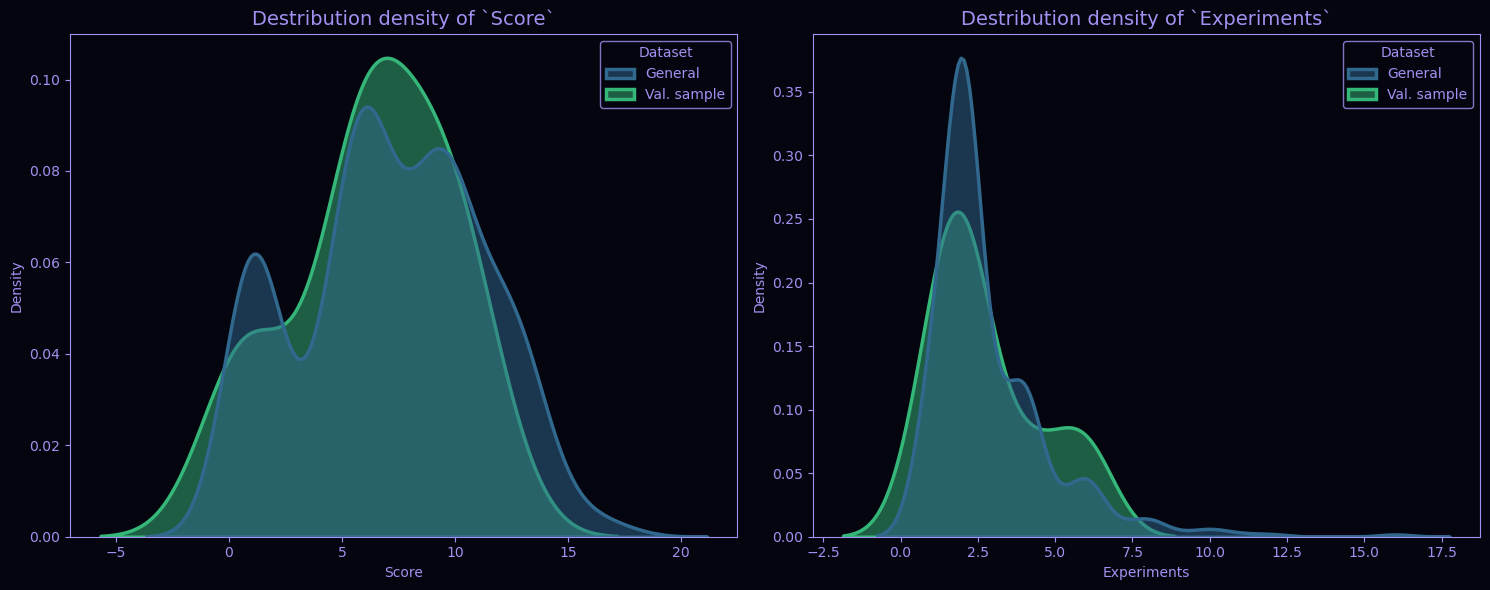

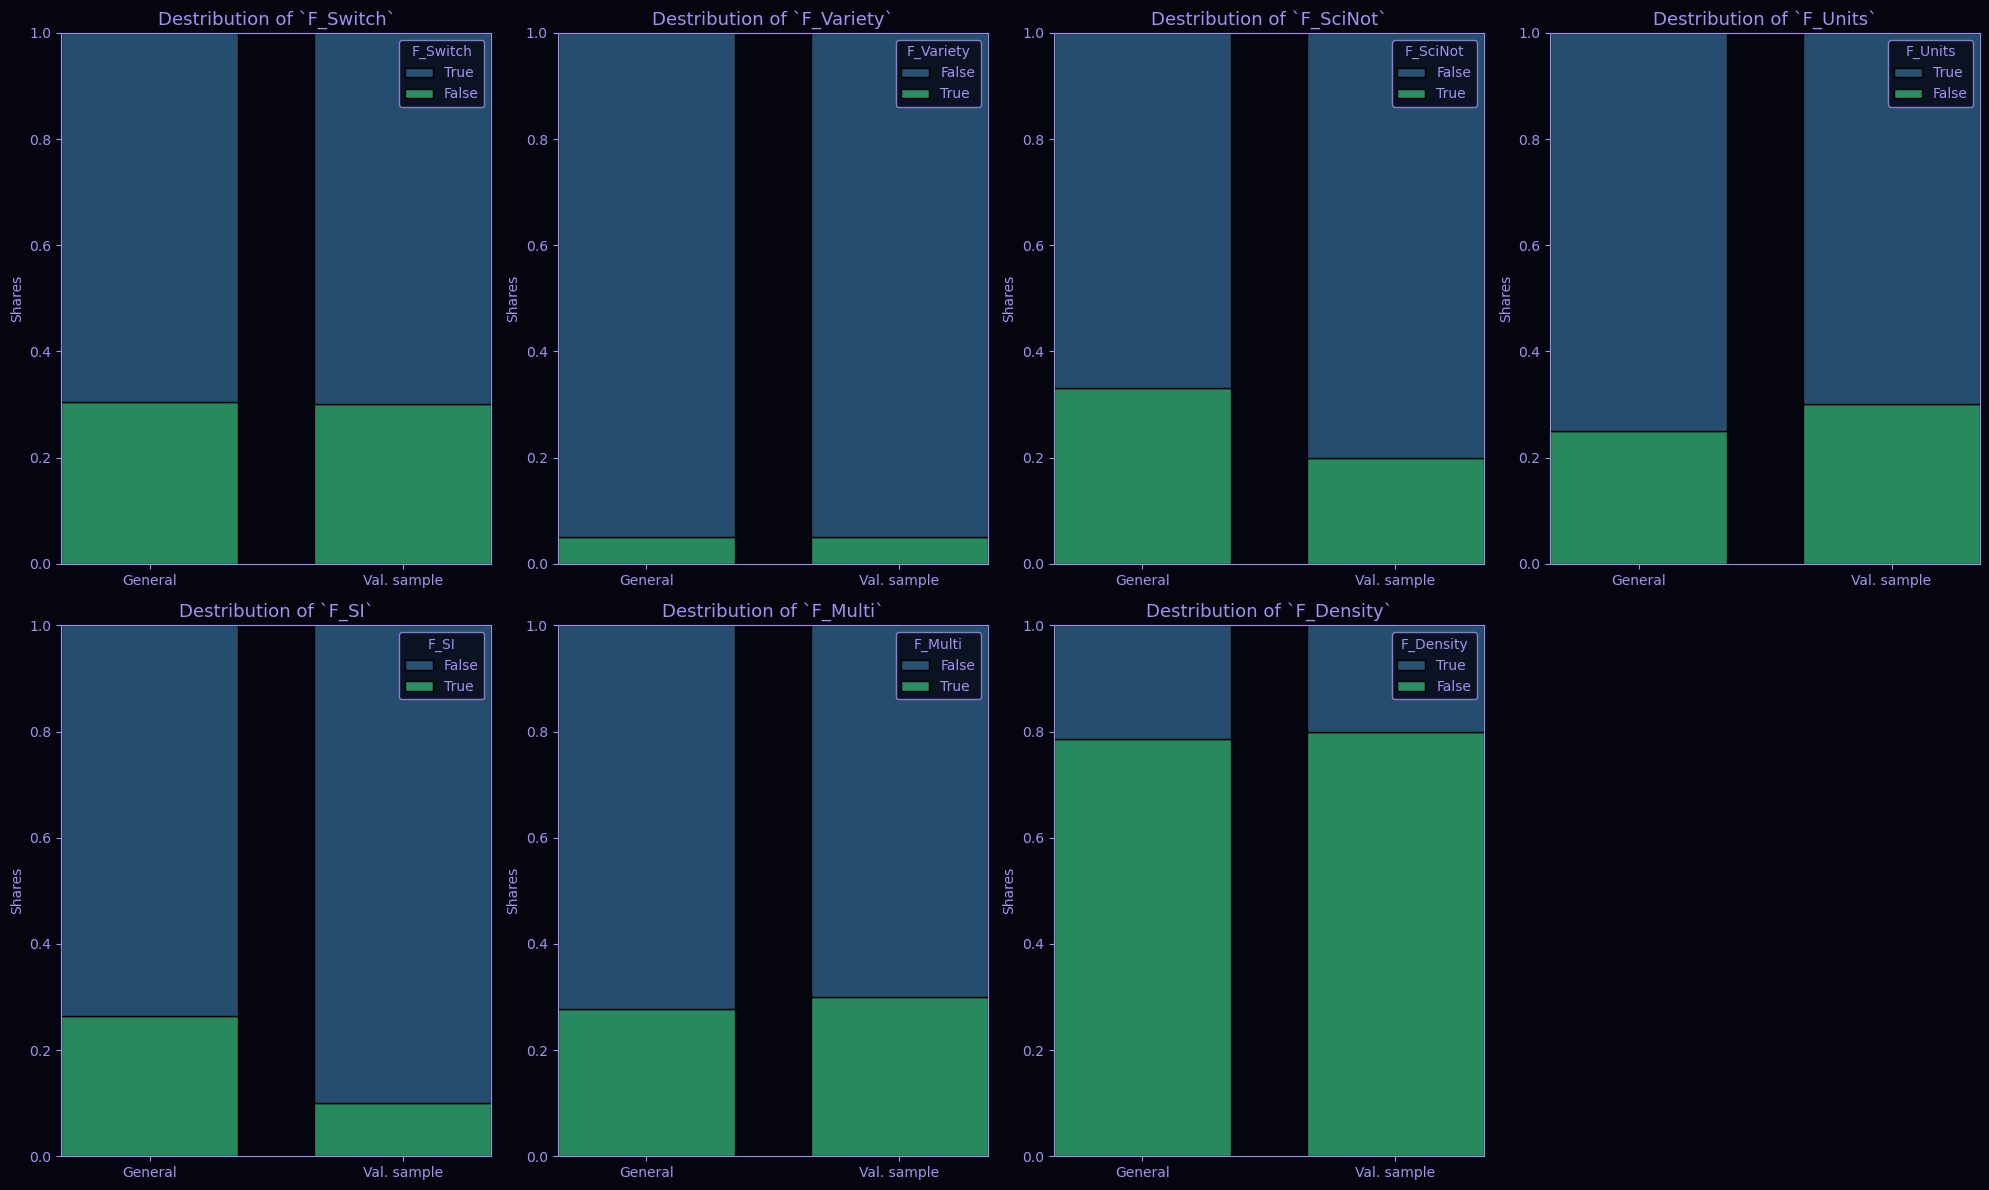

In [74]:
df_all = results.assign(Dataset='General')
df_test = results[results['DOI'].isin(val_dois)].assign(Dataset='Val. sample')
combined_df = pd.concat([df_all, df_test])

# Численные переменные
num_features = ['Score', 'Experiments']
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6))
for i, feature in enumerate(num_features):
    ax = axes1[i]
    sns.kdeplot(
        data=combined_df, x=feature, hue='Dataset', 
        fill=True, common_norm=False, palette='viridis', 
        alpha=0.5, linewidth=2.5, ax=ax
    )
    ax.set_title(f'Destribution density of `{feature}`', fontsize=14)
    ax.set_ylabel('Density')
    ax.set_xlabel(feature)
plt.tight_layout()
plt.show()

# Булевы переменные
bin_features = ['F_Switch', 'F_Variety', 'F_SciNot', 'F_Units', 'F_SI', 'F_Multi', 'F_Density']
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 12))
axes2 = axes2.flatten()
for i, feature in enumerate(bin_features):
    ax = axes2[i]
    temp_df = combined_df.copy()
    temp_df[feature] = temp_df[feature].astype(str)
    sns.histplot(
        data=temp_df, x='Dataset', hue=feature, 
        multiple='fill', shrink=0.7, ax=ax, 
        palette='viridis' 
    )
    ax.set_title(f'Destribution of `{feature}`', fontsize=13)
    ax.set_ylabel('Shares')
    ax.set_xlabel('')
if len(bin_features) < len(axes2):
    fig2.delaxes(axes2[-1])
plt.tight_layout()
plt.show()

## Тестовая выборка

In [65]:
remaining_pool = val_test_pool[~val_test_pool['DOI'].isin(val_dois)]

In [66]:
test_dois = []
for cluster_id, dois_count in cluster_plan.items():
    cluster_pool = remaining_pool[remaining_pool['Cluster'] == cluster_id]
    test_dois += cluster_pool.sample(
        min(dois_count, len(cluster_pool)),
        random_state=42
    )['DOI'].tolist()

print(test_dois)

['10.1021/acssuschemeng.8b04067', '10.1039/C7AY00750G', '10.1016/j.materresbull.2015.03.018', '10.1039/C6RA23773H', '10.1039/C8TB01132J', '10.1039/C7RA10370K', '10.1039/C6QM00149A', '10.1038/srep40103', '10.1016/j.colsurfa.2022.129887', '10.1021/jacs.7b00601', '10.1007/s00604-021-04942-7', '10.1016/j.msec.2018.10.038', '10.1016/j.microc.2019.104352', '10.1021/am501830v', '10.1021/acsomega.0c00147', '10.1016/j.snb.2021.130266', '10.1016/j.talanta.2021.122594', '10.1016/j.jpcs.2021.110534', '10.1039/C5RA11014A', '10.1016/j.snb.2017.06.175']


In [67]:
bad_doi_test = '10.1038/srep40103'

if bad_doi_test in test_dois:
    target_cluster_test = results[results['DOI'] == bad_doi_test]['Cluster'].values[0]

    forbidden_dois = set(val_dois) | set(test_dois)
    
    replacement_pool_test = remaining_pool[
        (remaining_pool['Cluster'] == target_cluster_test) & 
        (~remaining_pool['DOI'].isin(forbidden_dois))
    ]
    
    if not replacement_pool_test.empty:
        new_selected_test = replacement_pool_test.sort_values('Score', ascending=False).iloc[0]
        new_doi_test = new_selected_test['DOI']
        
        test_dois = [new_doi_test if x == bad_doi_test else x for x in test_dois]
        
        print(f"Статья {bad_doi_test} (Кластер {target_cluster_test}) успешно заменена на {new_doi_test}")
        print(f"Обновленный список Test DOIs: {test_dois}")
    else:
        print(f"Ошибка: В кластере {target_cluster_test} не осталось свободных статей для замены.")
else:
    print(f"Статья {bad_doi_test} не найдена в текущем списке test_dois.")

Статья 10.1038/srep40103 (Кластер 2) успешно заменена на 10.1021/acsami.2c20878
Обновленный список Test DOIs: ['10.1021/acssuschemeng.8b04067', '10.1039/C7AY00750G', '10.1016/j.materresbull.2015.03.018', '10.1039/C6RA23773H', '10.1039/C8TB01132J', '10.1039/C7RA10370K', '10.1039/C6QM00149A', '10.1021/acsami.2c20878', '10.1016/j.colsurfa.2022.129887', '10.1021/jacs.7b00601', '10.1007/s00604-021-04942-7', '10.1016/j.msec.2018.10.038', '10.1016/j.microc.2019.104352', '10.1021/am501830v', '10.1021/acsomega.0c00147', '10.1016/j.snb.2021.130266', '10.1016/j.talanta.2021.122594', '10.1016/j.jpcs.2021.110534', '10.1039/C5RA11014A', '10.1016/j.snb.2017.06.175']


Проверка распределения кластеров

In [68]:
remaining_pool[remaining_pool['DOI'].isin(test_dois)]['Cluster'].value_counts() \
    == cluster_plan

Cluster
0    True
2    True
1    True
3    True
dtype: bool

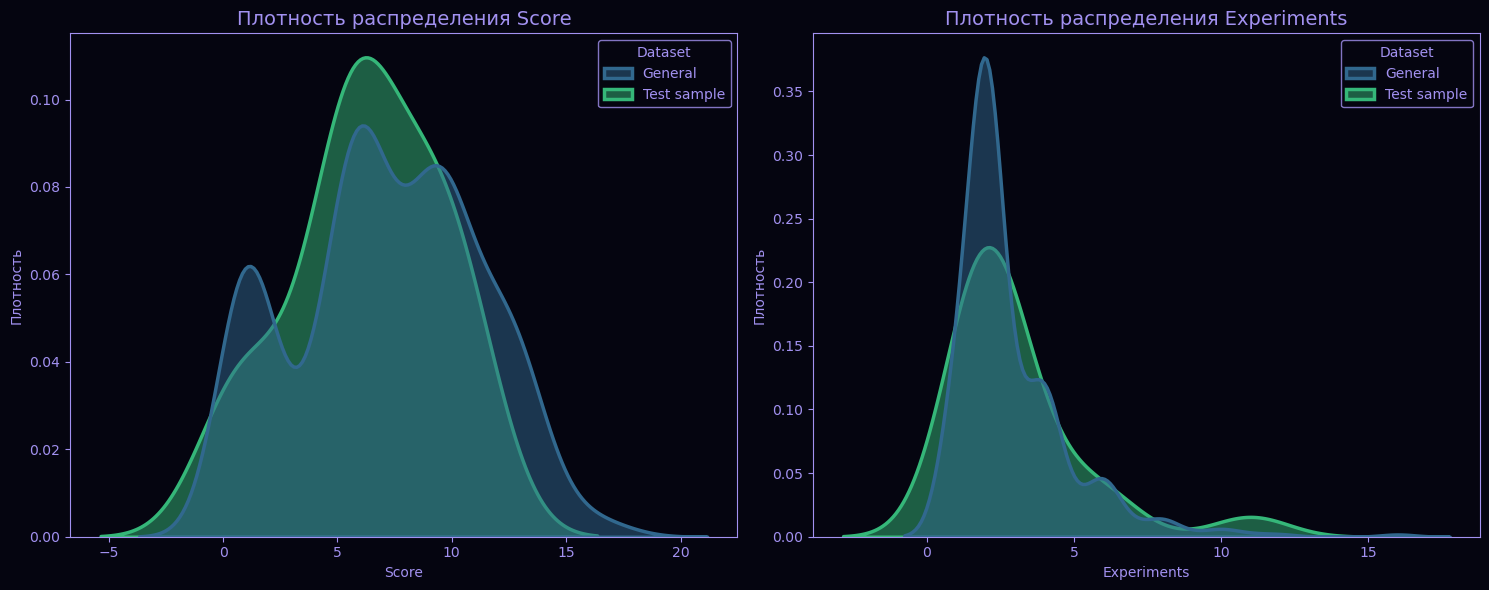

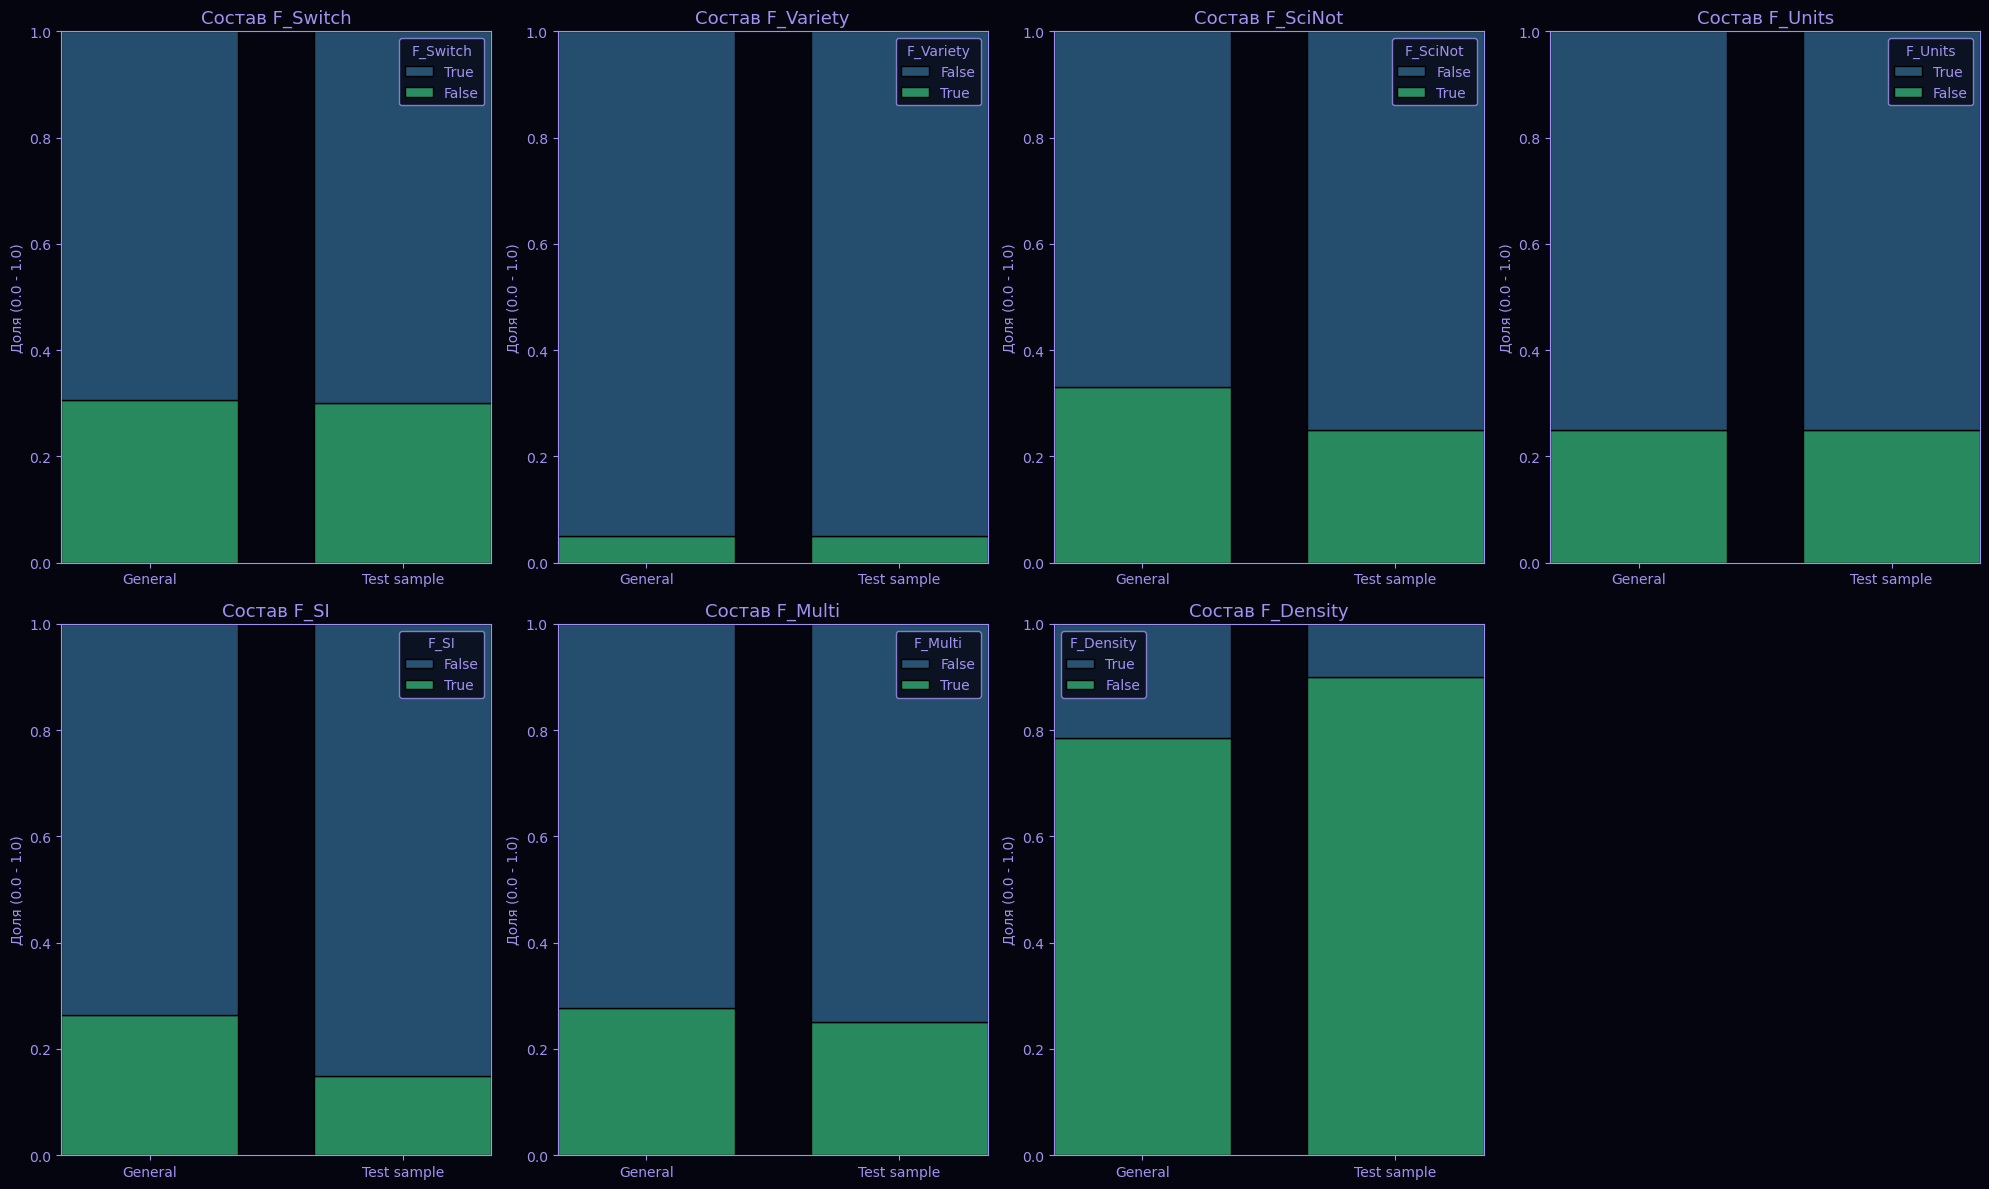

In [69]:
df_all = results.assign(Dataset='General')
df_test = results[results['DOI'].isin(test_dois)].assign(Dataset='Test sample')
combined_df = pd.concat([df_all, df_test])

# Численные переменные
num_features = ['Score', 'Experiments']
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6))
for i, feature in enumerate(num_features):
    ax = axes1[i]
    sns.kdeplot(
        data=combined_df, x=feature, hue='Dataset', 
        fill=True, common_norm=False, palette='viridis', 
        alpha=0.5, linewidth=2.5, ax=ax
    )
    ax.set_title(f'Плотность распределения {feature}', fontsize=14)
    ax.set_ylabel('Плотность')
    ax.set_xlabel(feature)
plt.tight_layout()
plt.show()

# Булевы переменные
bin_features = ['F_Switch', 'F_Variety', 'F_SciNot', 'F_Units', 'F_SI', 'F_Multi', 'F_Density']
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 12))
axes2 = axes2.flatten()
for i, feature in enumerate(bin_features):
    ax = axes2[i]
    temp_df = combined_df.copy()
    temp_df[feature] = temp_df[feature].astype(str)
    sns.histplot(
        data=temp_df, x='Dataset', hue=feature, 
        multiple='fill', shrink=0.7, ax=ax, 
        palette='viridis' 
    )
    ax.set_title(f'Состав {feature}', fontsize=13)
    ax.set_ylabel('Доля (0.0 - 1.0)')
    ax.set_xlabel('')
if len(bin_features) < len(axes2):
    fig2.delaxes(axes2[-1])
plt.tight_layout()
plt.show()

# Сохранение

In [70]:
# splits = {
#     "train_manual": train_manual_dois,
#     "train_auto": train_auto_dois,
#     "val": val_dois,
#     "test": test_dois
# }

# with open('../data/splits.json', 'w', encoding='utf-8') as f:
#     json.dump(splits, f, indent=4, ensure_ascii=False)